In [1]:
try:
  import google.colab
  %pip install -q ugropy
except ImportError:
  pass

## Failing fragmentations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ipqa-research/ugropy/blob/main/docs/source/tutorial/failing_fragmentations.ipynb)

`ugropy` may fail to obtain the subgroups of a molecule for a certain model for
two reasons: either there is a bug in the code, or the molecule cannot be
represented by the subgroups of the failing model.

`ugropy` utilizes SMARTS for the representation of functional groups to inquire
whether the molecule contains those structures. Let's examine the functional
group list for the classic liquid-vapor UNIFAC model.

In [2]:
from ugropy import unifac

unifac.subgroups

,smarts,molecular_weight
group,,
CH3,[CX4H3],15.03500
CH2,[CX4H2],14.02700
CH,[CX4H],13.01900
C,[CX4H0],12.01100
CH2=CH,[CH2]=[CH],27.04600
...,...,...
NCO,[NX2H0]=[CX2H0]=[OX1H0],42.01700
(CH2)2SU,[CH2]S(=O)(=O)[CH2],92.11620
CH2CHSU,[CH2]S(=O)(=O)[CH],91.10840


For example, let's check the SMARTS representation of the alcohol group ACOH:

In [3]:
unifac.subgroups.loc["ACOH", "smarts"]

'[cH0][OH]'

The SMARTS representation it's telling us that the `ACOH` group it's, of
course, a hydroxyl group bounded by a single bound to an aromatic carbon atom.

An example of a molecule that cannot be represented by UNIFAC groups:

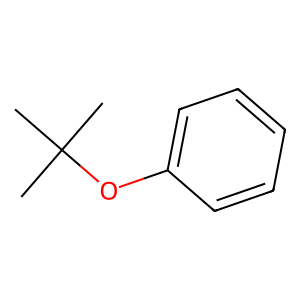

In [4]:
from rdkit.Chem import Draw


mol = unifac.get_groups("C1(=CC=CC=C1)OC(C)(C)C", "smiles")

Draw.MolToImage(mol.molecule)

In [5]:
print(mol.subgroups)

{}


The library "fails" to obtain any functional groups to accurately represent the
molecule. **This failure is represented by an empty dictionary**. In this case,
the "fail" is correct, but it could fail due to errors in the groups SMARTS
representations or the algorithm, resulting in an empty dictionary as well.
Currently, the supported models are tested against different molecules
available in the Tests Book section of the documentation.

If you encounter a failing representation, you can examine the structure of the
molecule and the list of functional groups of the failing model. If you
determine that the molecule can indeed be modeled, you may have discovered a
bug. Feel free to report the issue on the repository along with the failing
molecule's SMILES/name, the failing model and the `ugropy` version:

[https://github.com/ipqa-research/ugropy/issues](https://github.com/ipqa-research/ugropy/issues)

This could be useful in cases where some groups have more interaction
parameters than others in the mixture that you want to model with UNIFAC.
Alternatively, you can try both approaches and compare if there are any
differences.